In [1]:
# [Markdown]
# # 🛡️ Lab 03: Meta-Labeling (Risk & Sizing Model)
# **Objective:** Train the secondary CatBoost model for the `ChiefRiskOfficer` agent.
# - Load the pristine tensor and the trained Quantformer.
# - Generate base directional signals (The "Primary Model").
# - Apply the Triple-Barrier Method (Take Profit, Stop Loss, Time Limit) to find out which signals actually succeeded.
# - Train a CatBoost Classifier to predict the Probability of Success (Meta-Label).
# - Export `meta_model.cbm` for live sizing.

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt

# Re-define Quantformer for inference (MUST MATCH Notebook 02 exactly)
class Quantformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.proj = nn.Linear(num_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, 
            batch_first=True, dropout=0.2
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32), 
            nn.ReLU(), 
            nn.Dropout(0.2), 
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.fc(self.transformer(self.proj(x))[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"⚡ Compute Device: {device}")

⚡ Compute Device: mps


In [2]:
# [Markdown]
# ### 1. Run Inference to get Base Signals
# We feed the entire dataset through the trained Transformer to see what it *would* have traded.

# 1. Load Artifacts
save_dir = '../data/processed/'
df = pd.read_parquet(os.path.join(save_dir, 'clean_tensor.parquet')).dropna()
scaler = joblib.load(os.path.join(save_dir, 'core_scaler.pkl'))
pca = joblib.load(os.path.join(save_dir, 'core_pca.pkl'))
tech_features = joblib.load(os.path.join(save_dir, 'core_features.pkl'))
macro_cols = [c for c in df.columns if c.startswith('macro_emb_')]

# 2. Reconstruct Features
macro_pca = pca.transform(df[macro_cols])
X_raw = np.hstack([df[tech_features].values, macro_pca])
X_scaled = scaler.transform(X_raw)

# 3. Load Model
model = Quantformer(num_features=X_scaled.shape[1]).to(device)
model.load_state_dict(torch.load(os.path.join(save_dir, 'core_quantformer.pth'), map_location=device))
model.eval()

# 4. Generate Predictions (Sliding Window)
SEQ_LEN = 32
probabilities = np.full(len(df), np.nan)

print(f"🧠 Running Transformer Inference on {len(df)} bars...")
with torch.no_grad():
    for i in range(SEQ_LEN, len(df)):
        x_seq = X_scaled[i - SEQ_LEN : i]
        tensor_input = torch.tensor(x_seq, dtype=torch.float32).unsqueeze(0).to(device)
        logit = model(tensor_input)
        probabilities[i] = torch.sigmoid(logit).item()

df['base_prob'] = probabilities

# Filter for "Active Setups" (High conviction trades only: e.g., <35% for short, >65% for long)
df['base_signal'] = np.select(
    [df['base_prob'] > 0.65, df['base_prob'] < 0.35],
    [1, -1], # 1 = LONG, -1 = SHORT
    default=0
)

active_setups = df[df['base_signal'] != 0].copy()
print(f"🎯 Total Active Setups generated by Transformer: {len(active_setups)}")

🧠 Running Transformer Inference on 99987 bars...
🎯 Total Active Setups generated by Transformer: 49417


In [6]:
# [Markdown]
# ### 2. Triple-Barrier Meta-Labeling
# For every active setup, did it hit Take Profit (Label=1), or did it hit Stop Loss / Friday Close (Label=0)?
# This logic must exactly match `agents/chief_agent.py`.

def apply_triple_barrier(full_df, setups_df, horizon=480):
    print("🚧 Applying Triple-Barrier Method (SL, TP, Time Limit)...")
    meta_labels = []
    
    close_arr = full_df['close'].values
    high_arr = full_df['high'].values
    low_arr = full_df['low'].values
    dow_arr = full_df.index.dayofweek.values
    hour_arr = full_df.index.hour.values
    
    # Get positional indices of setups in the full dataframe
    setup_indices = full_df.index.get_indexer(setups_df.index)
    
    for loc in setup_indices:
        if loc + 1 >= len(full_df): 
            meta_labels.append(np.nan)
            continue
            
        direction = full_df.iloc[loc]['base_signal']
        entry_price = close_arr[loc]
        
        # Risk Parameters (Matched to Chief Agent)
        atr = full_df.iloc[loc]['atr']
        if pd.isna(atr): atr = 0.0010 # Fallback
            
        # Standard: 1.5 ATR Stop, 3.0 ATR Take Profit (1:2 R:R)
        stop_dist = (atr / 100) * entry_price * 1.5 
        take_dist = stop_dist * 2.0
        
        stop_price = entry_price - (direction * stop_dist)
        take_price = entry_price + (direction * take_dist)
        
        end_loc = min(loc + horizon + 1, len(full_df))
        future_highs = high_arr[loc+1 : end_loc]
        future_lows = low_arr[loc+1 : end_loc]
        
        if direction == 1:
            stops = np.where(future_lows <= stop_price)[0]
            takes = np.where(future_highs >= take_price)[0]
        else:
            stops = np.where(future_highs >= stop_price)[0]
            takes = np.where(future_lows <= take_price)[0]
            
        # Friday 21:00 Time Stop
        future_dow = dow_arr[loc+1 : end_loc]
        future_hour = hour_arr[loc+1 : end_loc]
        fridays = np.where((future_dow == 4) & (future_hour >= 21))[0]
        
        stop_idx = stops[0] if len(stops) > 0 else 9999
        take_idx = takes[0] if len(takes) > 0 else 9999
        time_idx = fridays[0] if len(fridays) > 0 else 9999
        
        first_event = min(take_idx, stop_idx, time_idx)
        
        if first_event == 9999:
            meta_labels.append(0) # Never hit targets
        elif first_event == take_idx:
            meta_labels.append(1) # SUCCESS!
        else:
            meta_labels.append(0) # FAILURE (SL or Friday Close)
            
    setups_df['meta_label'] = meta_labels
    return setups_df.dropna(subset=['meta_label'])

labeled_setups = apply_triple_barrier(df, active_setups)
win_rate = labeled_setups['meta_label'].mean()
print(f"📊 Base Strategy Win Rate (Before Meta-Model): {win_rate:.2%}")


🚧 Applying Triple-Barrier Method (SL, TP, Time Limit)...
📊 Base Strategy Win Rate (Before Meta-Model): 27.92%


In [ ]:
# [Markdown]
# ### 3. Train the Meta-Model (CatBoost)
# The Transformer found the direction. Now, CatBoost looks at volatility, session, and structure to predict the probability that the Transformer is right.

# We only train on the features, not the macro embeddings (keep CatBoost fast and focused on structure)
meta_features = tech_features + ['active_session_name'] 
cat_features = ['active_session_name']

X_meta = labeled_setups[meta_features].copy()
y_meta = labeled_setups['meta_label'].astype(int)

# Ensure string type for categorical
X_meta['active_session_name'] = X_meta['active_session_name'].astype(str)

split_idx = int(len(X_meta) * 0.8)
X_train, X_val = X_meta.iloc[:split_idx], X_meta.iloc[split_idx:]
y_train, y_val = y_meta.iloc[:split_idx], y_meta.iloc[split_idx:]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

meta_model = CatBoostClassifier(
    iterations=500, 
    learning_rate=0.03, 
    depth=5, 
    eval_metric='Logloss', 
    random_seed=42, 
    early_stopping_rounds=50, 
    verbose=100
)

print("🚀 Training CatBoost Risk Filter...")
meta_model.fit(train_pool, eval_set=val_pool)

🚀 Training CatBoost Risk Filter...
0:	learn: 0.6805801	test: 0.6802566	best: 0.6802566 (0)	total: 9.91ms	remaining: 4.94s
100:	learn: 0.3983096	test: 0.4945632	best: 0.4893215 (60)	total: 1.03s	remaining: 4.07s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4893214955
bestIteration = 60

Shrink model to first 61 iterations.


CatBoostClassifier(depth=5, early_stopping_rounds=50, eval_metric='Logloss', iterations=500, learning_rate=0.03, random_seed=42, verbose=100)

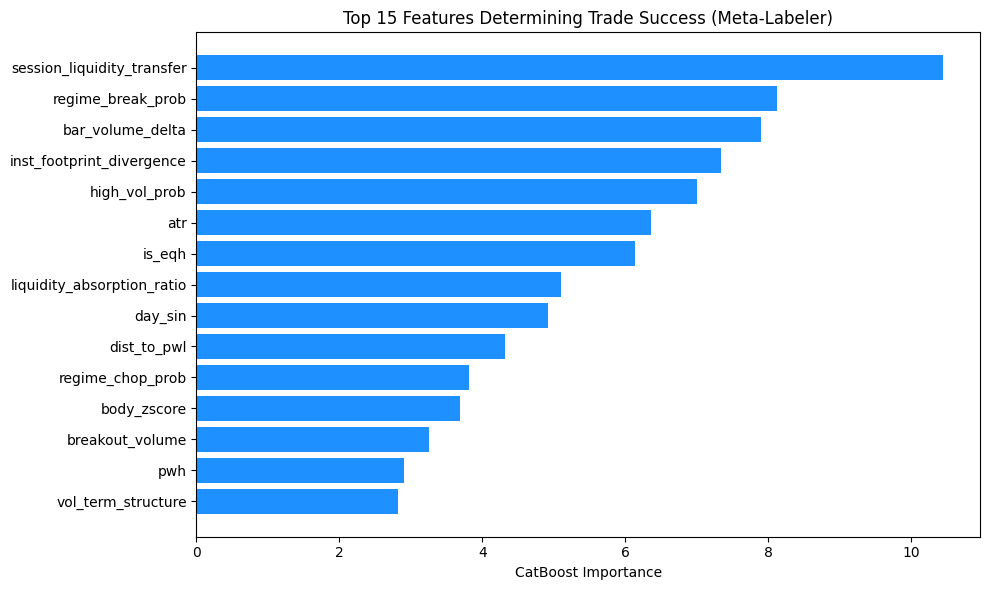

✅ Meta-Model successfully exported to: ../models/meta_model.cbm


In [8]:
# [Markdown]
# ### 4. Feature Importance & Export
# Let's see what the Chief Risk Officer cares about most when vetoing a trade.

importance = meta_model.get_feature_importance()
imp_df = pd.DataFrame({'Feature': meta_features, 'Importance': importance}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'].head(15)[::-1], imp_df['Importance'].head(15)[::-1], color='dodgerblue')
plt.title("Top 15 Features Determining Trade Success (Meta-Labeler)")
plt.xlabel("CatBoost Importance")
plt.tight_layout()
plt.show()

# Export Model
model_path = '../models/meta_model.cbm'
os.makedirs('../models', exist_ok=True)
meta_model.save_model(model_path)
print(f"✅ Meta-Model successfully exported to: {model_path}")